## Synthetic experiments

In [1]:
from pathlib import Path
import importlib
import sys
import matplotlib.pyplot as plt
from matplotlib.colors import to_hex
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.transforms import ScaledTranslation
from matplotlib.legend_handler import HandlerBase
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import kurtosis, skew

ROOT = Path.cwd().resolve()
if not (ROOT / 'utils.py').exists():
    raise FileNotFoundError('Run this notebook from the project root containing utils.py')
sys.path.insert(0, str(ROOT.resolve()))
FIGURE_DIR = ROOT / 'figure'
RESULTS_DIR = ROOT / 'results'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
import utils
importlib.reload(utils)
from utils import (generate_synthetic_data, make_three_way_split,
                   evaluate_baseline_family, evaluate_penalized_dqr_family,
                   save_numeric_results)

SEED = 42
N_SAMPLES = 5000
SPLIT_FRACTIONS = (0.70, 0.20, 0.10)
SCENARIOS = ['homoscedastic_normal', 'heteroscedastic_lognormal',
             'heteroscedastic_loglaplace']
MAIN_MODELS = ['LQR', 'QRF', 'QXGBoost', 'HMIC-DQR']
TRAINING = dict(max_epochs=1000, patience=80, batch_size=256,
                quantile_weight=0.05, interval_weight=0.15,
                temperature=0.05, penalty_warmup_epochs=20)
plt.rcdefaults()
plt.rcParams.update({
    'font.family': 'Times New Roman', 'mathtext.fontset': 'stix',
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})

# Twelve-level discrete coolwarm palette used only by the manuscript figures.
COOLWARM_12 = [
    to_hex(plt.get_cmap('coolwarm', 12)(index)) for index in range(12)
]
FOUR_MODEL_COLORS = {
    model: COOLWARM_12[index]
    for model, index in zip(
        ('LQR', 'QRF', 'QXGBoost', 'HMIC-DQR'), (1, 4, 7, 10)
    )
}
DQR_FAMILY_COLORS = {
    model: COOLWARM_12[index]
    for model, index in zip(('DQR', 'MIC-DQR', 'HMIC-DQR'), (2, 6, 10))
}
DQR_FAMILY_COLORS['best-HMIC-DQR'] = DQR_FAMILY_COLORS['HMIC-DQR']

# Consistent marker/line semantics across all model-comparison figures.
FOUR_MODEL_STYLES = {
    model: dict(
        marker='s' if model == 'HMIC-DQR' else 'o',
        linestyle='-', linewidth=1.25, markersize=3.2,
    )
    for model in ('LQR', 'QRF', 'QXGBoost', 'HMIC-DQR')
}
DQR_FAMILY_STYLES = {
    model: dict(
        marker='s' if model in ('HMIC-DQR', 'best-HMIC-DQR') else 'o',
        linestyle='--', linewidth=1.25, markersize=3.2,
    )
    for model in ('DQR', 'MIC-DQR', 'HMIC-DQR', 'best-HMIC-DQR')
}


class _HandlerCenteredLineAboveBar(HandlerBase):
    """Draw one centered marker above a bar swatch under one shared label."""

    def create_artists(
            self, legend, orig_handle, xdescent, ydescent,
            width, height, fontsize, trans):
        line_proxy, bar_proxy = orig_handle
        center_y = 0.20 * height - ydescent
        bar = Rectangle(
            (xdescent, center_y - 0.37 * height), width, 0.30 * height,
            facecolor=bar_proxy.get_facecolor(),
            edgecolor=bar_proxy.get_edgecolor(),
            linewidth=bar_proxy.get_linewidth(),
            alpha=bar_proxy.get_alpha(), transform=trans,
        )
        y_line = center_y + 0.22 * height
        line = Line2D(
            [xdescent, xdescent + width], [y_line, y_line],
            color=line_proxy.get_color(),
            linestyle=line_proxy.get_linestyle(),
            linewidth=line_proxy.get_linewidth(),
            marker=None, transform=trans,
        )
        marker = Line2D(
            [xdescent + 0.50 * width], [y_line],
            color=line_proxy.get_color(), linestyle='None',
            marker=line_proxy.get_marker(),
            markersize=line_proxy.get_markersize(),
            markerfacecolor=line_proxy.get_markerfacecolor(),
            markeredgecolor=line_proxy.get_markeredgecolor(),
            transform=trans,
        )
        return [bar, line, marker]


class _HandlerShiftedIdeal(HandlerBase):
    """Draw the Ideal line slightly lower without moving model markers."""

    def create_artists(
            self, legend, orig_handle, xdescent, ydescent,
            width, height, fontsize, trans):
        y_line = 0.38 * height - ydescent
        line = Line2D(
            [xdescent, xdescent + width], [y_line, y_line],
            color=orig_handle.get_color(),
            linestyle=orig_handle.get_linestyle(),
            linewidth=orig_handle.get_linewidth(),
            marker=orig_handle.get_marker(),
            markersize=orig_handle.get_markersize(), transform=trans)
        return [line]


def lower_legend_text(legend, figure, offset_points=1.5):
    """Lower legend labels while leaving model handles unchanged."""
    offset = ScaledTranslation(
        0, -offset_points / 72, figure.dpi_scale_trans)
    for legend_text in legend.get_texts():
        legend_text.set_verticalalignment('center')
        legend_text.set_transform(legend_text.get_transform() + offset)

# Experimental design

Each synthetic dataset is generated in memory with 5,000 observations and analytically known conditional quantiles. Every method uses the same 70%/20%/10% train/validation/test split, DQR-family checkpoints are selected by validation WIS, and all reported measures are computed on the untouched test subset.


In [2]:
rows = []
bundles = {}
for scenario in SCENARIOS:
    data = generate_synthetic_data(
        scenario=scenario, n_samples=N_SAMPLES, seed=SEED)
    split = make_three_way_split(
        len(data['y']), seed=SEED, fractions=SPLIT_FRACTIONS)
    baseline = evaluate_baseline_family(
        data['X'], data['y'], split, seed=SEED,
        true_quantiles=data['true_quantiles'])
    penalized = evaluate_penalized_dqr_family(
        data['X'], data['y'], split, model_seed=SEED,
        train_kwargs=TRAINING, true_quantiles=data['true_quantiles'])
    metrics = pd.concat(
        [baseline['metrics'], penalized['metrics']], ignore_index=True)
    scenario_label = str(data['scenario_display_name'])
    metrics.insert(0, 'scenario', scenario)
    metrics.insert(1, 'scenario_label', scenario_label)
    metrics.insert(2, 'data_seed', SEED)
    metrics.insert(3, 'model_seed', SEED)
    metrics.insert(4, 'split_protocol', '70:20:10')
    rows.append(metrics)

    predictions = dict(baseline['predictions'])
    predictions.update({
        'DQR': penalized['predictions']['base'],
        'MIC-DQR': penalized['predictions']['mic'],
        'HMIC-DQR': penalized['predictions']['hmic'],
    })
    bundles[scenario] = {
        'label': scenario_label,
        'data': data,
        'split': split,
        'baseline': baseline,
        'penalized': penalized,
        'predictions': predictions,
    }

synthetic_results = pd.concat(rows, ignore_index=True)
save_numeric_results(
    synthetic_results, RESULTS_DIR / 'synthetic_penalized_dqr_metrics.csv')

### Main model comparison

In [3]:
model_order = pd.CategoricalDtype(MAIN_MODELS, ordered=True)
main_table = synthetic_results.loc[
    synthetic_results['model'].isin(MAIN_MODELS),
    ['scenario_label', 'model', 'wis',
     'mean_quantile_calibration_error',
     'mean_interval_coverage_error', 'mean_interval_width',
     'true_quantile_rmse']
].copy()
main_table['model'] = main_table['model'].astype(model_order)
main_table = main_table.sort_values(['scenario_label', 'model']).reset_index(drop=True)
main_table = main_table.rename(columns={
    'scenario_label': 'Scenario',
    'model': 'Model',
    'wis': 'WIS',
    'mean_quantile_calibration_error': 'QCE',
    'mean_interval_coverage_error': 'Coverage error',
    'mean_interval_width': 'MPIW',
    'true_quantile_rmse': 'True-quantile RMSE',
})
display(main_table.style.format({
    'WIS': '{:.3f}', 'QCE': '{:.3f}', 'Coverage error': '{:.3f}',
    'MPIW': '{:.3f}', 'True-quantile RMSE': '{:.3f}',
}))

,Scenario,Model,WIS,QCE,Coverage error,MPIW,True-quantile RMSE
0,Heteroscedastic log-Laplace,LQR,1.698,0.015,0.015,4.000,3.283
1,Heteroscedastic log-Laplace,QRF,0.854,0.029,0.059,2.203,1.056
2,Heteroscedastic log-Laplace,QXGBoost,0.856,0.008,0.010,1.781,1.176
3,Heteroscedastic log-Laplace,HMIC-DQR,0.806,0.011,0.012,1.573,0.675
4,Heteroscedastic lognormal,LQR,1.988,0.006,0.003,4.537,3.227
5,Heteroscedastic lognormal,QRF,1.299,0.008,0.007,2.933,1.187
6,Heteroscedastic lognormal,QXGBoost,1.348,0.015,0.030,2.604,1.309
7,Heteroscedastic lognormal,HMIC-DQR,1.275,0.018,0.030,2.524,0.932
8,Homoscedastic Gaussian,LQR,0.473,0.006,0.010,1.147,0.552
9,Homoscedastic Gaussian,QRF,0.364,0.014,0.010,0.840,0.208


### Synthetic distributions, quantile recovery, and interval calibration

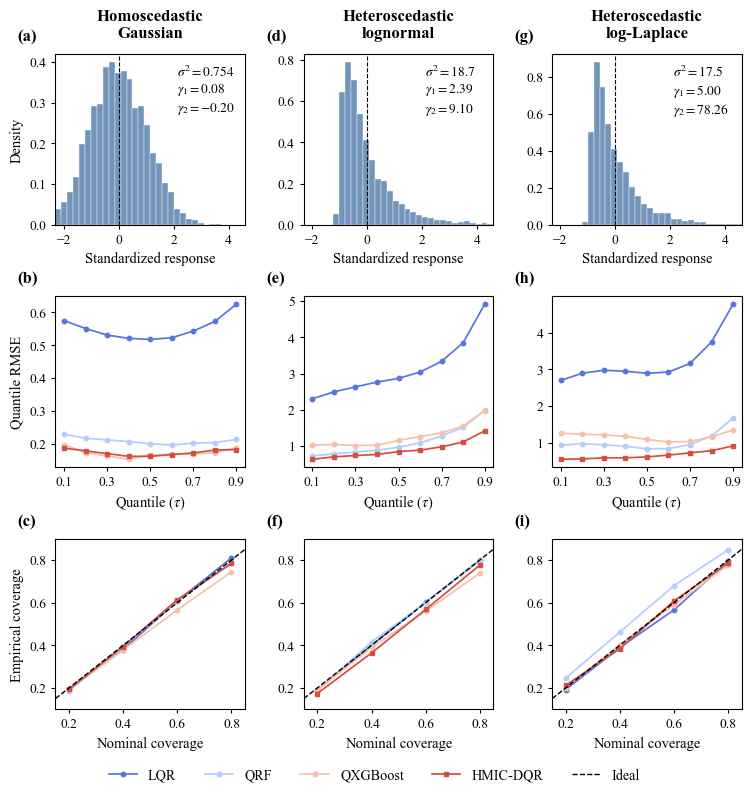

In [4]:
main_figure_data = {}
for scenario, bundle in bundles.items():
    predictions = {
        model: bundle['predictions'][model] for model in MAIN_MODELS
    }
    test_indices = bundle['split']['test']
    main_figure_data[bundle['label']] = {
        'distribution_y': bundle['data']['y'],
        'y': bundle['data']['y'][test_indices],
        'true_quantiles': bundle['data']['true_quantiles'][test_indices],
        'predictions': predictions,
    }

quantiles = np.asarray(utils.DEFAULT_QUANTILES, dtype=float)
fig_01, axes = plt.subplots(
    3, len(main_figure_data), figsize=(7.5, 7.8), squeeze=False,
    sharex='row',
)
panel_letters = iter('abcdefghijklmnopqrstuvwxyz')
legend_handles = None
legend_labels = None
standardized_distributions = {}
for scenario, payload in main_figure_data.items():
    values = np.asarray(payload.get('distribution_y', payload['y']), dtype=float)
    standardized_distributions[scenario] = (values - values.mean()) / values.std(ddof=0)
pooled = np.concatenate(list(standardized_distributions.values()))
distribution_limits = np.quantile(pooled, [0.0025, 0.9975])

for column, (scenario, payload) in enumerate(main_figure_data.items()):
    y = np.asarray(payload['y'], dtype=float).reshape(-1)
    predictions = payload['predictions']
    model_order = utils._ordered_prediction_models(predictions)
    rmse_table = utils.quantile_rmse_by_model(
        payload['true_quantiles'], predictions, quantiles
    )

    distribution_axis = axes[0, column]
    raw_y = np.asarray(payload.get('distribution_y', y), dtype=float)
    distribution_axis.hist(
        standardized_distributions[scenario], bins=32,
        range=tuple(distribution_limits), density=True,
        color='#4C78A8', alpha=0.78, edgecolor='white', linewidth=0.35,
    )
    distribution_axis.axvline(
        0.0, color='black', linewidth=0.8, linestyle='--'
    )
    scenario_title = scenario.replace(' ', '\n', 1)
    distribution_axis.set_title(
        scenario_title, fontsize=12, fontweight='bold', pad=12
    )
    distribution_axis.set_xlabel('Standardized response')
    if column == 0:
        distribution_axis.set_ylabel('Density')
    distribution_axis.set_xlim(distribution_limits)
    distribution_axis.text(
        0.64, 0.94,
        rf"$\sigma^2 = {np.var(raw_y):.3g}$" "\n"
        rf"$\gamma_1 = {skew(raw_y, bias=False):.2f}$" "\n"
        rf"$\gamma_2 = {kurtosis(raw_y, fisher=True, bias=False):.2f}$",
        transform=distribution_axis.transAxes, ha='left', va='top',
        fontsize=9.6, clip_on=True,
    )
    distribution_axis.text(
        -0.20, 1.06, f'({next(panel_letters)})',
        transform=distribution_axis.transAxes, fontsize=12,
        fontweight='bold', va='bottom',
    )

    rmse_axis = axes[1, column]
    for model in model_order:
        values = rmse_table.loc[rmse_table['model'].eq(model)]
        rmse_axis.plot(
            values['quantile'], values['true_quantile_rmse'],
            color=FOUR_MODEL_COLORS[model], label=model,
            **FOUR_MODEL_STYLES[model],
        )
    rmse_axis.set_xlabel(r'Quantile ($\tau$)')
    if column == 0:
        rmse_axis.set_ylabel('Quantile RMSE')
    rmse_axis.set_xticks(quantiles[::2])
    rmse_axis.text(
        -0.20, 1.06, f'({next(panel_letters)})',
        transform=rmse_axis.transAxes, fontsize=12,
        fontweight='bold', va='bottom',
    )
    if legend_handles is None:
        legend_handles, legend_labels = rmse_axis.get_legend_handles_labels()

    coverage_axis = axes[2, column]
    for model in model_order:
        prediction = np.asarray(predictions[model], dtype=float)
        lower, upper = utils.base_central_intervals(prediction)
        table = utils.interval_metrics_table(y, lower, upper)
        coverage_axis.plot(
            table['nominal_coverage'], table['empirical_coverage'],
            color=FOUR_MODEL_COLORS[model], label=model,
            **FOUR_MODEL_STYLES[model],
        )
    coverage_axis.plot(
        [0.15, 0.85], [0.15, 0.85], color='black', linestyle='--',
        linewidth=1.0, label='Ideal',
    )
    coverage_axis.set(
        xlabel='Nominal coverage', xlim=(0.15, 0.85), ylim=(0.10, 0.90),
    )
    if column == 0:
        coverage_axis.set_ylabel('Empirical coverage')
    coverage_axis.set_xticks([0.2, 0.4, 0.6, 0.8])
    coverage_axis.text(
        -0.20, 1.06, f'({next(panel_letters)})',
        transform=coverage_axis.transAxes, fontsize=12,
        fontweight='bold', va='bottom',
    )

    for axis in axes[:, column]:
        axis.grid(False)
        axis.tick_params(
            axis='both', which='major', bottom=True, left=True,
            direction='out', length=3.0, width=0.8,
            labelsize=9.8,
        )
        axis.xaxis.label.set_size(10.5)
        axis.yaxis.label.set_size(10.5)

ideal_handles, ideal_labels = axes[2, 0].get_legend_handles_labels()
legend_handles = list(legend_handles) + [ideal_handles[-1]]
legend_labels = list(legend_labels) + [ideal_labels[-1]]
fig_01.legend(
    legend_handles, legend_labels, loc='lower center', ncol=5,
    frameon=False, bbox_to_anchor=(0.5, 0.01), fontsize=10.2,
)
fig_01.subplots_adjust(
    left=0.075, right=0.99, top=0.96, bottom=0.12,
    wspace=0.31, hspace=0.42,
)
plt.show()
fig_01.savefig(FIGURE_DIR / 'Fig_03.png', dpi=600, bbox_inches='tight', facecolor='white')
fig_01.savefig(FIGURE_DIR / 'Fig_03.pdf', bbox_inches='tight', facecolor='white')

##  Ablation outputs

In [5]:
ablation_models = ['DQR', 'MIC-DQR', 'HMIC-DQR']
ablation_columns = [
    'scenario_label', 'model', 'wis',
    'mean_quantile_calibration_error',
    'mean_interval_coverage_error', 'mean_interval_width',
    'true_quantile_rmse', 'crossing_rate',
    'nesting_violation_rate',
]
ablation_table = synthetic_results.loc[
    synthetic_results['model'].isin(ablation_models), ablation_columns
].copy()
ablation_order = pd.CategoricalDtype(ablation_models, ordered=True)
ablation_table['model'] = ablation_table['model'].astype(ablation_order)
ablation_table = ablation_table.sort_values(
    ['scenario_label', 'model']).reset_index(drop=True)
ablation_table = ablation_table.rename(columns={
    'scenario_label': 'Scenario',
    'model': 'Model',
    'wis': 'WIS',
    'mean_quantile_calibration_error': 'QCE',
    'mean_interval_coverage_error': 'Coverage error',
    'mean_interval_width': 'MPIW',
    'true_quantile_rmse': 'True-quantile RMSE',
    'crossing_rate': 'Crossing rate',
    'nesting_violation_rate': 'Nesting violation rate',
})
display(ablation_table.style.format({
    'WIS': '{:.3f}', 'QCE': '{:.3f}', 'Coverage error': '{:.3f}',
    'MPIW': '{:.3f}', 'True-quantile RMSE': '{:.3f}',
    'Crossing rate': '{:.3f}', 'Nesting violation rate': '{:.3f}',
}))

,Scenario,Model,WIS,QCE,Coverage error,MPIW,True-quantile RMSE,Crossing rate,Nesting violation rate
0,Heteroscedastic log-Laplace,DQR,0.818,0.026,0.030,1.513,0.678,0.000,0.000
1,Heteroscedastic log-Laplace,MIC-DQR,0.799,0.021,0.005,1.668,0.643,0.000,0.000
2,Heteroscedastic log-Laplace,HMIC-DQR,0.806,0.011,0.012,1.573,0.675,0.000,0.000
3,Heteroscedastic lognormal,DQR,1.279,0.043,0.024,2.565,0.958,0.000,0.000
4,Heteroscedastic lognormal,MIC-DQR,1.282,0.022,0.032,2.518,0.939,0.000,0.000
5,Heteroscedastic lognormal,HMIC-DQR,1.275,0.018,0.030,2.524,0.932,0.000,0.000
6,Homoscedastic Gaussian,DQR,0.358,0.008,0.011,0.803,0.168,0.000,0.000
7,Homoscedastic Gaussian,MIC-DQR,0.359,0.007,0.010,0.819,0.173,0.000,0.000
8,Homoscedastic Gaussian,HMIC-DQR,0.359,0.012,0.010,0.817,0.173,0.000,0.000


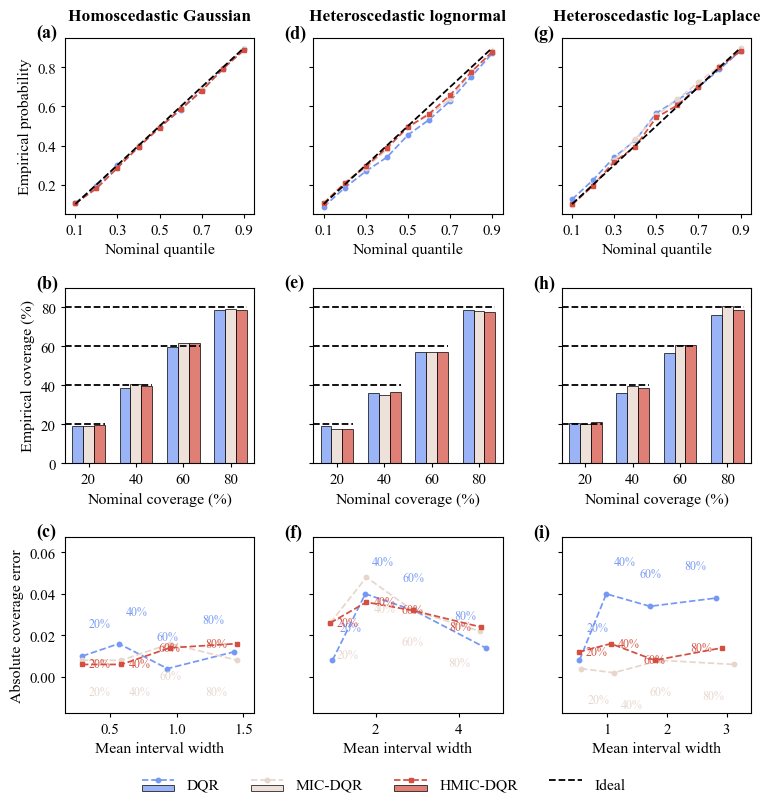

In [6]:
ablation_figure_data = {
    bundle['label']: {
        'y': bundle['data']['y'][bundle['split']['test']],
        'predictions': {
            model: bundle['predictions'][model]
            for model in ('DQR', 'MIC-DQR', 'HMIC-DQR')
        },
    }
    for bundle in bundles.values()
}

quantiles = np.asarray(utils.DEFAULT_QUANTILES, dtype=float)
model_order = ['DQR', 'MIC-DQR', 'HMIC-DQR', 'best-HMIC-DQR']
styles = DQR_FAMILY_STYLES
fig_s01, axes = plt.subplots(
    3, len(ablation_figure_data), figsize=(7.5, 7.8), squeeze=False,
    sharey='row',
)
panel_letters = iter('abcdefghijklmnopqrstuvwxyz')
legend_handles = None
legend_labels = None

for column, (experiment_name, payload) in enumerate(ablation_figure_data.items()):
    y = np.asarray(payload['y'], dtype=float).reshape(-1)
    predictions = payload['predictions']
    available = [name for name in model_order if name in predictions]
    calibration_axis = axes[0, column]
    coverage_axis = axes[1, column]
    tradeoff_axis = axes[2, column]
    interval_tables = {}
    calibration_axis.set_title(
        experiment_name, fontsize=12.5, fontweight='bold', pad=13)

    for model in available:
        prediction = np.asarray(predictions[model])
        calibration = utils.quantile_calibration_table(y, prediction, quantiles)
        calibration_axis.plot(
            calibration['quantile'], calibration['empirical_probability'],
            color=DQR_FAMILY_COLORS[model], label=model,
            **styles[model],
        )
        lower, upper = utils.base_central_intervals(prediction)
        interval_tables[model] = utils.interval_metrics_table(y, lower, upper)
    calibration_axis.plot(
        [0.1, 0.9], [0.1, 0.9], 'k--', linewidth=1.3, label='Ideal'
    )
    calibration_axis.set(xlim=(0.05, 0.95), ylim=(0.05, 0.95))
    calibration_axis.set_xticks(quantiles[::2])
    calibration_axis.set_xlabel('Nominal quantile')
    if column == 0:
        calibration_axis.set_ylabel('Empirical probability')
        legend_handles, legend_labels = calibration_axis.get_legend_handles_labels()

    nominal = interval_tables[available[0]]['nominal_coverage'].to_numpy()
    x_positions = np.arange(len(nominal))
    width = 0.23
    for offset, model in enumerate(available):
        table = interval_tables[model]
        coverage_axis.bar(
            x_positions + (offset - 1) * width,
            table['empirical_coverage'], width=width,
            color=DQR_FAMILY_COLORS[model], alpha=0.72,
            edgecolor='black', linewidth=0.7, label=model,
        )
    group_half_width = 1.5 * width
    coverage_xlim = (-0.50, len(nominal) - 0.50)
    coverage_axis.set_xlim(coverage_xlim)
    coverage_left = coverage_xlim[0]
    for group_center, nominal_level in zip(x_positions, nominal):
        coverage_axis.plot(
            [coverage_left, group_center + group_half_width],
            [nominal_level, nominal_level],
            color='black', linestyle='--', linewidth=1.3,
            solid_capstyle='butt', zorder=4,
        )
    coverage_axis.set_xticks(x_positions)
    coverage_axis.set_xticklabels([f'{100 * value:.0f}' for value in nominal])
    coverage_axis.set_xlim(coverage_xlim)
    coverage_axis.set_ylim(0, 0.90)
    coverage_axis.set_xlabel('Nominal coverage (%)')
    if column == 0:
        coverage_axis.set_ylabel('Empirical coverage (%)')
    coverage_axis.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda value, _: f'{100 * value:.0f}')
    )

    for model in available:
        table = interval_tables[model]
        tradeoff_axis.plot(
            table['mean_interval_width'], table['absolute_coverage_error'],
            color=DQR_FAMILY_COLORS[model], label=model,
            **styles[model],
        )
        label_dy = {'DQR': 23, 'MIC-DQR': -23,
                    'HMIC-DQR': 0, 'best-HMIC-DQR': 0}[model]
        for _, record in table.iterrows():
            is_rightmost = np.isclose(
                record['mean_interval_width'],
                table['mean_interval_width'].max())
            nominal_value = float(record['nominal_coverage'])
            if is_rightmost:
                dx, horizontal_alignment = -7, 'right'
            elif np.isclose(nominal_value, 0.60):
                dx, horizontal_alignment = 0, 'center'
            else:
                dx, horizontal_alignment = 5, 'left'
            tradeoff_axis.annotate(
                f"{nominal_value:.0%}",
                (record['mean_interval_width'],
                 record['absolute_coverage_error']),
                xytext=(dx, label_dy), textcoords='offset points',
                fontsize=8.7, color=DQR_FAMILY_COLORS[model],
                ha=horizontal_alignment, va='center',
                annotation_clip=True, clip_on=True,
            )
    tradeoff_axis.margins(x=0.11, y=0.42)
    tradeoff_axis.set_xlabel('Mean interval width')
    if column == 0:
        tradeoff_axis.set_ylabel('Absolute coverage error')

    for axis in axes[:, column]:
        axis.grid(False)
        axis.tick_params(
            axis='both', which='major', bottom=True, left=True,
            direction='out', length=3.0, width=0.8, labelsize=10.8,
        )
        axis.xaxis.label.set_size(11.5)
        axis.yaxis.label.set_size(11.5)
        axis.text(
            -0.15, 0.98, f'({next(panel_letters)})',
            transform=axis.transAxes, fontsize=13,
            fontweight='bold', va='bottom',
        )

combined_handles_s01 = [
    (
        Line2D([], [], color=DQR_FAMILY_COLORS[model],
               **styles[model]),
        Rectangle((0, 0), 1, 1, facecolor=DQR_FAMILY_COLORS[model],
                  edgecolor='black', linewidth=0.7, alpha=0.72),
    )
    for model in ('DQR', 'MIC-DQR', 'HMIC-DQR')
]
ideal_handle_s01 = Line2D(
    [], [], color='black', linestyle='--', linewidth=1.3)
legend_s01 = fig_s01.legend(
    combined_handles_s01 + [ideal_handle_s01],
    ['DQR', 'MIC-DQR', 'HMIC-DQR', 'Ideal'],
    handler_map={
        tuple: _HandlerCenteredLineAboveBar(),
        ideal_handle_s01: _HandlerShiftedIdeal(),
    },
    loc='lower center', ncol=4, frameon=False,
    bbox_to_anchor=(0.5, 0.006), fontsize=11.2,
    handleheight=1.55, handlelength=2.1,
)
lower_legend_text(legend_s01, fig_s01)
fig_s01.subplots_adjust(
    left=0.075, right=0.99, top=0.985, bottom=0.12,
    wspace=0.31, hspace=0.42,
)
plt.show()
fig_s01.savefig(FIGURE_DIR / 'Fig_S02.png', dpi=600, bbox_inches='tight', facecolor='white')
fig_s01.savefig(FIGURE_DIR / 'Fig_S02.pdf', bbox_inches='tight', facecolor='white')